# 1차 모델 성능 테스트 및 비교

여러 모델의 성능을 평가하고 비교 분석하는 노트북입니다.

## 1. 라이브러리 및 모듈 임포트

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
import pickle
import joblib
import warnings
import os
import glob
from collections import defaultdict
from datetime import datetime
import json
warnings.filterwarnings('ignore')

import platform
from matplotlib import font_manager, rc

plt.rcParams["axes.unicode_minus"] = False
if platform.system() == "Windows":
    font_path = "C:/Windows/Fonts/malgun.ttf"
    font_name = font_manager.FontProperties(fname=font_path).get_name()
    rc("font", family=font_name)
else:
    rc("font", family="AppleGothic")

# 결과 저장용 딕셔너리
model_results = {}
model_predictions = {}

## 2. 데이터 로드 및 전처리

In [5]:
import os
import pandas as pd
import numpy as np

# 테스트 데이터 로드 경로
test_data_path = "../../dataset/시나리오통화테스트셋.csv"


test_data = pd.read_csv(test_data_path)
print("테스트 데이터를 성공적으로 불러왔습니다.")

# 데이터 요약
print(f"\n테스트 데이터 크기: {test_data.shape}")
print("\n테스트 데이터 기본 정보:")
test_data.info()
print("\n첫 5행:")
print(test_data.head())

# 결측값 확인
print("\n결측값 확인:")
print(test_data.isnull().sum())

# 타겟 변수 분포 및 특성 분리
target_column = "is_phishing"
if target_column in test_data.columns:
    print(f"\n타겟 변수 '{target_column}' 분포:")
    print(test_data[target_column].value_counts())

    # 특성과 타겟 분리
    X_test = test_data["text"].astype(str)
    y_test = test_data[target_column]

    print(f"\n테스트 샘플 개수: {len(X_test)}")
else:
    print(f"⚠ 경고: 타겟 컬럼 '{target_column}'을 찾을 수 없습니다.")
    print(f"사용 가능한 컬럼: {test_data.columns.tolist()}")

테스트 데이터를 성공적으로 불러왔습니다.

테스트 데이터 크기: (20, 3)

테스트 데이터 기본 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   file_id      20 non-null     object
 1   text         20 non-null     object
 2   is_phishing  20 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 608.0+ bytes

첫 5행:
      file_id                                               text  is_phishing
0  phishing_1  네, 여보세요.\n네, 여보세요. 서울지방경찰청 사이퍼 범죄추사팀 박민선 승사관입니...            1
1  phishing_2  고객님, 안녕하세요. 농협캐피탈입니다.\n고객님은 신용등급 상향 대상자로 선정되셔서...            1
2  phishing_3  여보세요? 엄마 나야 나 지금 핸드폰 애 저 깨졌어, 친구 폰으로 연락했어.\n누구...            1
3  phishing_4  네, 여보세요, 고객님, 안녕하세요, 로젠택배입니다, 고객님. 택배가 주소 의류로 ...            1
4  phishing_5  네, 안녕하세요. 국민건강보험공단입니다. 고객님.\n작년 과오납 환급금이 47만원 ...            1

결측값 확인:
file_id        0
text           0
is_phishing    0
dtype: int64

타겟 변수 'is_phishing' 분포:
is_ph

In [6]:
from sklearn.metrics import classification_report
import pandas as pd  # pandas 누락
from kiwipiepy import Kiwi  # kiwi 토크나이저
import joblib  #  모델 불러오기


# ✅ tokenizer 함수 정의

kiwi = Kiwi()


def tokenize_and_filter(text):
    result = kiwi.analyze(text)[0][0]
    tokens = []
    for word, pos, _, _ in result:
        if pos in {"NNG", "NNP", "VV", "VA"}:
            if pos in {"VV", "VA"}:
                word = word + "다"
            tokens.append(word)
    return " ".join(tokens)

## 3. 다중 모델 로드 및 관리

In [ ]:
# 모델 경로 설정 및 자동 탐지
model_paths = {
    "LogisticRegression_단일": "../models/logistic_v1.pkl",
    "LogisticRegression_복합": "../models/logistic2_v2.pkl",
    "통합데이터셋로지스틱1": "../models/logistic_v2.pkl",
    "통합데이터셋로지스틱2": "../models/logistic3_v2.pkl",
    "Bagging": "../models/Bagging.pkl",
    "Stacking": "../models/stacking.pkl",
}

# 실제 존재하는 모델 파일 찾기
models = {}
model_info = {}

# 모델 디렉토리에서 자동으로 모델 파일 찾기
model_dir = '../../models/'
if os.path.exists(model_dir):
    model_files = glob.glob(os.path.join(model_dir, '*.pkl')) + glob.glob(os.path.join(model_dir, '*.joblib'))
    print(f"발견된 모델 파일들: {[os.path.basename(f) for f in model_files]}")

    for file_path in model_files:
        model_name = os.path.splitext(os.path.basename(file_path))[0]
        try:
            model = joblib.load(file_path)  # ← pickle 대신 joblib 고정
            models[model_name] = model
            model_info[model_name] = {
                "path": file_path,
                "type": type(model).__name__,
                "loaded": True,
            }
            print(f"✓ {model_name} 모델 로드 성공 (타입: {type(model).__name__})")
        except Exception as e:
            print(f"✗ {model_name} 모델 로드 실패: {e}")
            model_info[model_name] = {
                "path": file_path,
                "type": "Unknown",
                "loaded": False,
                "error": str(e),
            }
else:
    print("모델 디렉토리가 존재하지 않습니다.")

print(f"\n로드된 모델 수: {len(models)}")
for name, info in model_info.items():
    if info['loaded']:
        print(f"- {name}: {info['type']}")
    else:
        print(f"- {name}: 로드 실패 ({info.get('error', 'Unknown error')})")

발견된 모델 파일들: ['Bagging_v1.pkl', 'logistic2_v1.pkl', 'logistic3_v2.pkl', 'logistic_v1.pkl', 'logistic_v2.pkl', 'stacking_v1.pkl']
✓ Bagging_v1 모델 로드 성공 (타입: Pipeline)
✓ logistic2_v1 모델 로드 성공 (타입: Pipeline)
✓ logistic3_v2 모델 로드 성공 (타입: Pipeline)
✓ logistic_v1 모델 로드 성공 (타입: Pipeline)
✓ logistic_v2 모델 로드 성공 (타입: LogisticRegression)
✓ stacking_v1 모델 로드 성공 (타입: Pipeline)

로드된 모델 수: 6
- Bagging_v1: Pipeline
- logistic2_v1: Pipeline
- logistic3_v2: Pipeline
- logistic_v1: Pipeline
- logistic_v2: LogisticRegression
- stacking_v1: Pipeline


## 4. 각 모델별 성능 평가

In [8]:
# 각 모델에 대해 예측 및 성능 평가 수행 (개선된 버전)
def evaluate_model_enhanced(model, X_test, y_test, model_name):
    """단일 모델의 성능을 평가하는 개선된 함수"""
    try:
        # 모든 모델에 대해 일관된 토큰화 적용
        # 학습 시에도 tokenize_and_filter를 사용했으므로 테스트 시에도 동일하게 적용
        if type(model).__name__ == 'LogisticRegression':
            # LogisticRegression 단독 모델인 경우 - 벡터화된 데이터 필요
            print(f"[{model_name}] LogisticRegression 단독 모델 - 토큰화 후 별도 벡터화 필요")
            print("⚠️ 이 모델은 이미 벡터화된 데이터를 기대하므로 현재 설정으로는 평가할 수 없습니다.")
            return None
        else:
            # 모든 Pipeline 모델에 대해 토큰화 적용 (학습 시와 동일한 전처리)
            print(f"[{model_name}] 토큰화 적용 후 모델 평가")
            X_processed = X_test.apply(tokenize_and_filter)
        
        # 예측 수행
        y_pred = model.predict(X_processed)
        
        # 예측 확률 계산 (가능한 경우)
        try:
            y_pred_proba = model.predict_proba(X_processed)[:, 1]  # 양성 클래스 확률
        except:
            y_pred_proba = None
        
        # 성능 지표 계산
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        
        # 이진 분류 전용 지표
        if len(np.unique(y_test)) == 2:
            precision_binary = precision_score(y_test, y_pred, zero_division=0)
            recall_binary = recall_score(y_test, y_pred, zero_division=0)
            f1_binary = f1_score(y_test, y_pred, zero_division=0)
        else:
            precision_binary = recall_binary = f1_binary = None
        
        # AUC 계산 (이진 분류인 경우)
        try:
            if y_pred_proba is not None and len(np.unique(y_test)) == 2:
                auc = roc_auc_score(y_test, y_pred_proba)
            else:
                auc = None
        except:
            auc = None
        
        # 혼동 행렬
        cm = confusion_matrix(y_test, y_pred)
        
        # 분류 리포트
        target_names = ['정상대화', '보이스피싱'] if len(np.unique(y_test)) == 2 else None
        cls_report = classification_report(y_test, y_pred, target_names=target_names, output_dict=True)
        
        # 결과 저장
        results = {
            'model_name': model_name,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'precision_binary': precision_binary,
            'recall_binary': recall_binary,
            'f1_binary': f1_binary,
            'auc': auc,
            'predictions': y_pred,
            'probabilities': y_pred_proba,
            'confusion_matrix': cm,
            'classification_report': cls_report,
            'classification_report_text': classification_report(y_test, y_pred, target_names=target_names)
        }
        
        return results
        
    except Exception as e:
        print(f"모델 {model_name} 평가 중 오류 발생: {e}")
        return None

# 모든 모델 평가 (개선된 버전)
print("=== 개선된 모델 성능 평가 시작 ===")
print("📝 모든 Pipeline 모델에 학습 시와 동일한 tokenize_and_filter 적용")
print()

for model_name, model in models.items():
    print(f"\n{model_name} 모델 평가 중...")
    result = evaluate_model_enhanced(model, X_test, y_test, model_name)

    if result:
        model_results[model_name] = result
        model_predictions[model_name] = {
            'predictions': result['predictions'],
            'probabilities': result['probabilities']
        }

        print(f"✓ {model_name} 평가 완료")
        print(f"  - 정확도: {result['accuracy']:.4f}")
        print(f"  - F1-Score (weighted): {result['f1_score']:.4f}")
        if result['f1_binary'] is not None:
            print(f"  - F1-Score (binary): {result['f1_binary']:.4f}")
        print(f"  - Recall: {result['recall']:.4f}")
        if result["auc"]:
            print(f"  - AUC: {result['auc']:.4f}")
            
        # 상세 분류 리포트 출력
        print(f"\n{model_name} 상세 성능:")
        print(result['classification_report_text'])
        print("-" * 50)
    else:
        print(f"✗ {model_name} 평가 실패 - 스킵")

print(f"\n총 {len(model_results)}개 모델 평가 완료")

=== 개선된 모델 성능 평가 시작 ===
📝 모든 Pipeline 모델에 학습 시와 동일한 tokenize_and_filter 적용


Bagging_v1 모델 평가 중...
[Bagging_v1] 토큰화 적용 후 모델 평가
✓ Bagging_v1 평가 완료
  - 정확도: 0.9000
  - F1-Score (weighted): 0.8990
  - F1-Score (binary): 0.9091
  - Recall: 0.9000
  - AUC: 0.9650

Bagging_v1 상세 성능:
              precision    recall  f1-score   support

        정상대화       1.00      0.80      0.89        10
       보이스피싱       0.83      1.00      0.91        10

    accuracy                           0.90        20
   macro avg       0.92      0.90      0.90        20
weighted avg       0.92      0.90      0.90        20

--------------------------------------------------

logistic2_v1 모델 평가 중...
[logistic2_v1] 토큰화 적용 후 모델 평가
✓ logistic2_v1 평가 완료
  - 정확도: 0.8500
  - F1-Score (weighted): 0.8465
  - F1-Score (binary): 0.8696
  - Recall: 0.8500
  - AUC: 0.9800

logistic2_v1 상세 성능:
              precision    recall  f1-score   support

        정상대화       1.00      0.70      0.82        10
       보이스피싱       0.77  

## 5. 모델 성능 비교표

In [9]:
# 모델 성능 비교표 생성 (개선된 버전)
if model_results:
    comparison_data = []
    for model_name, results in model_results.items():
        row = {
            'Model': model_name,
            'Accuracy': results['accuracy'],
            'Precision (weighted)': results['precision'],
            'Recall (weighted)': results['recall'],
            'F1-Score (weighted)': results['f1_score']
        }
        
        # 이진 분류 지표 추가
        if results['precision_binary'] is not None:
            row['Precision (binary)'] = results['precision_binary']
            row['Recall (binary)'] = results['recall_binary']
            row['F1-Score (binary)'] = results['f1_binary']
        
        if results['auc'] is not None:
            row['AUC'] = results['auc']
            
        comparison_data.append(row)
    
    comparison_df = pd.DataFrame(comparison_data)
    
    # 성능 순으로 정렬 (F1-Score weighted 기준)
    comparison_df = comparison_df.sort_values('F1-Score (weighted)', ascending=False)
    
    print("=== 개선된 모델 성능 비교표 ===")
    print(comparison_df.round(4))
    
    # 최고 성능 모델 찾기
    best_model = comparison_df.iloc[0]['Model']
    best_f1 = comparison_df.iloc[0]['F1-Score (weighted)']
    
    print(f"\n🏆 최고 성능 모델: {best_model}")
    print(f"   F1-Score (weighted): {best_f1:.4f}")
    
    # 이진 분류 F1-Score도 있다면 표시
    if 'F1-Score (binary)' in comparison_df.columns:
        best_f1_binary = comparison_df.iloc[0]['F1-Score (binary)']
        print(f"   F1-Score (binary): {best_f1_binary:.4f}")
    
    # 성능 차이 분석
    if len(comparison_df) > 1:
        worst_f1 = comparison_df.iloc[-1]['F1-Score (weighted)']
        improvement = ((best_f1 - worst_f1) / worst_f1) * 100
        print(f"📈 최고-최저 성능 차이: {improvement:.1f}%")
        
    # 각 모델별 예측 확률 샘플 출력
    print("\n=== 모델별 예측 확률 샘플 (상위 10개) ===")
    for model_name, results in model_results.items():
        if results['probabilities'] is not None:
            print(f"\n[{model_name}] 예측 확률 샘플:")
            
            # 결과 데이터프레임 생성
            sample_df = pd.DataFrame({
                'text': test_data['text'].iloc[:10],
                'true_label': y_test.iloc[:10],
                'predicted_label': results['predictions'][:10],
                'phishing_probability': results['probabilities'][:10]
            })
            
            # 확률 정렬하여 상위 예시 표시
            sample_df_sorted = sample_df.sort_values('phishing_probability', ascending=False)
            print(sample_df_sorted[['true_label', 'predicted_label', 'phishing_probability']].head(5))
            print("-" * 60)
            
else:
    print("평가된 모델이 없습니다.")

=== 개선된 모델 성능 비교표 ===
          Model  Accuracy  Precision (weighted)  Recall (weighted)  \
4   stacking_v1      0.95                0.9545               0.95   
0    Bagging_v1      0.90                0.9167               0.90   
1  logistic2_v1      0.85                0.8846               0.85   
2  logistic3_v2      0.85                0.8846               0.85   
3   logistic_v1      0.85                0.8846               0.85   

   F1-Score (weighted)  Precision (binary)  Recall (binary)  \
4               0.9499              0.9091              1.0   
0               0.8990              0.8333              1.0   
1               0.8465              0.7692              1.0   
2               0.8465              0.7692              1.0   
3               0.8465              0.7692              1.0   

   F1-Score (binary)    AUC  
4             0.9524  0.980  
0             0.9091  0.965  
1             0.8696  0.980  
2             0.8696  0.980  
3             0.8696  0.980 

## 6. 모델 비교 시각화

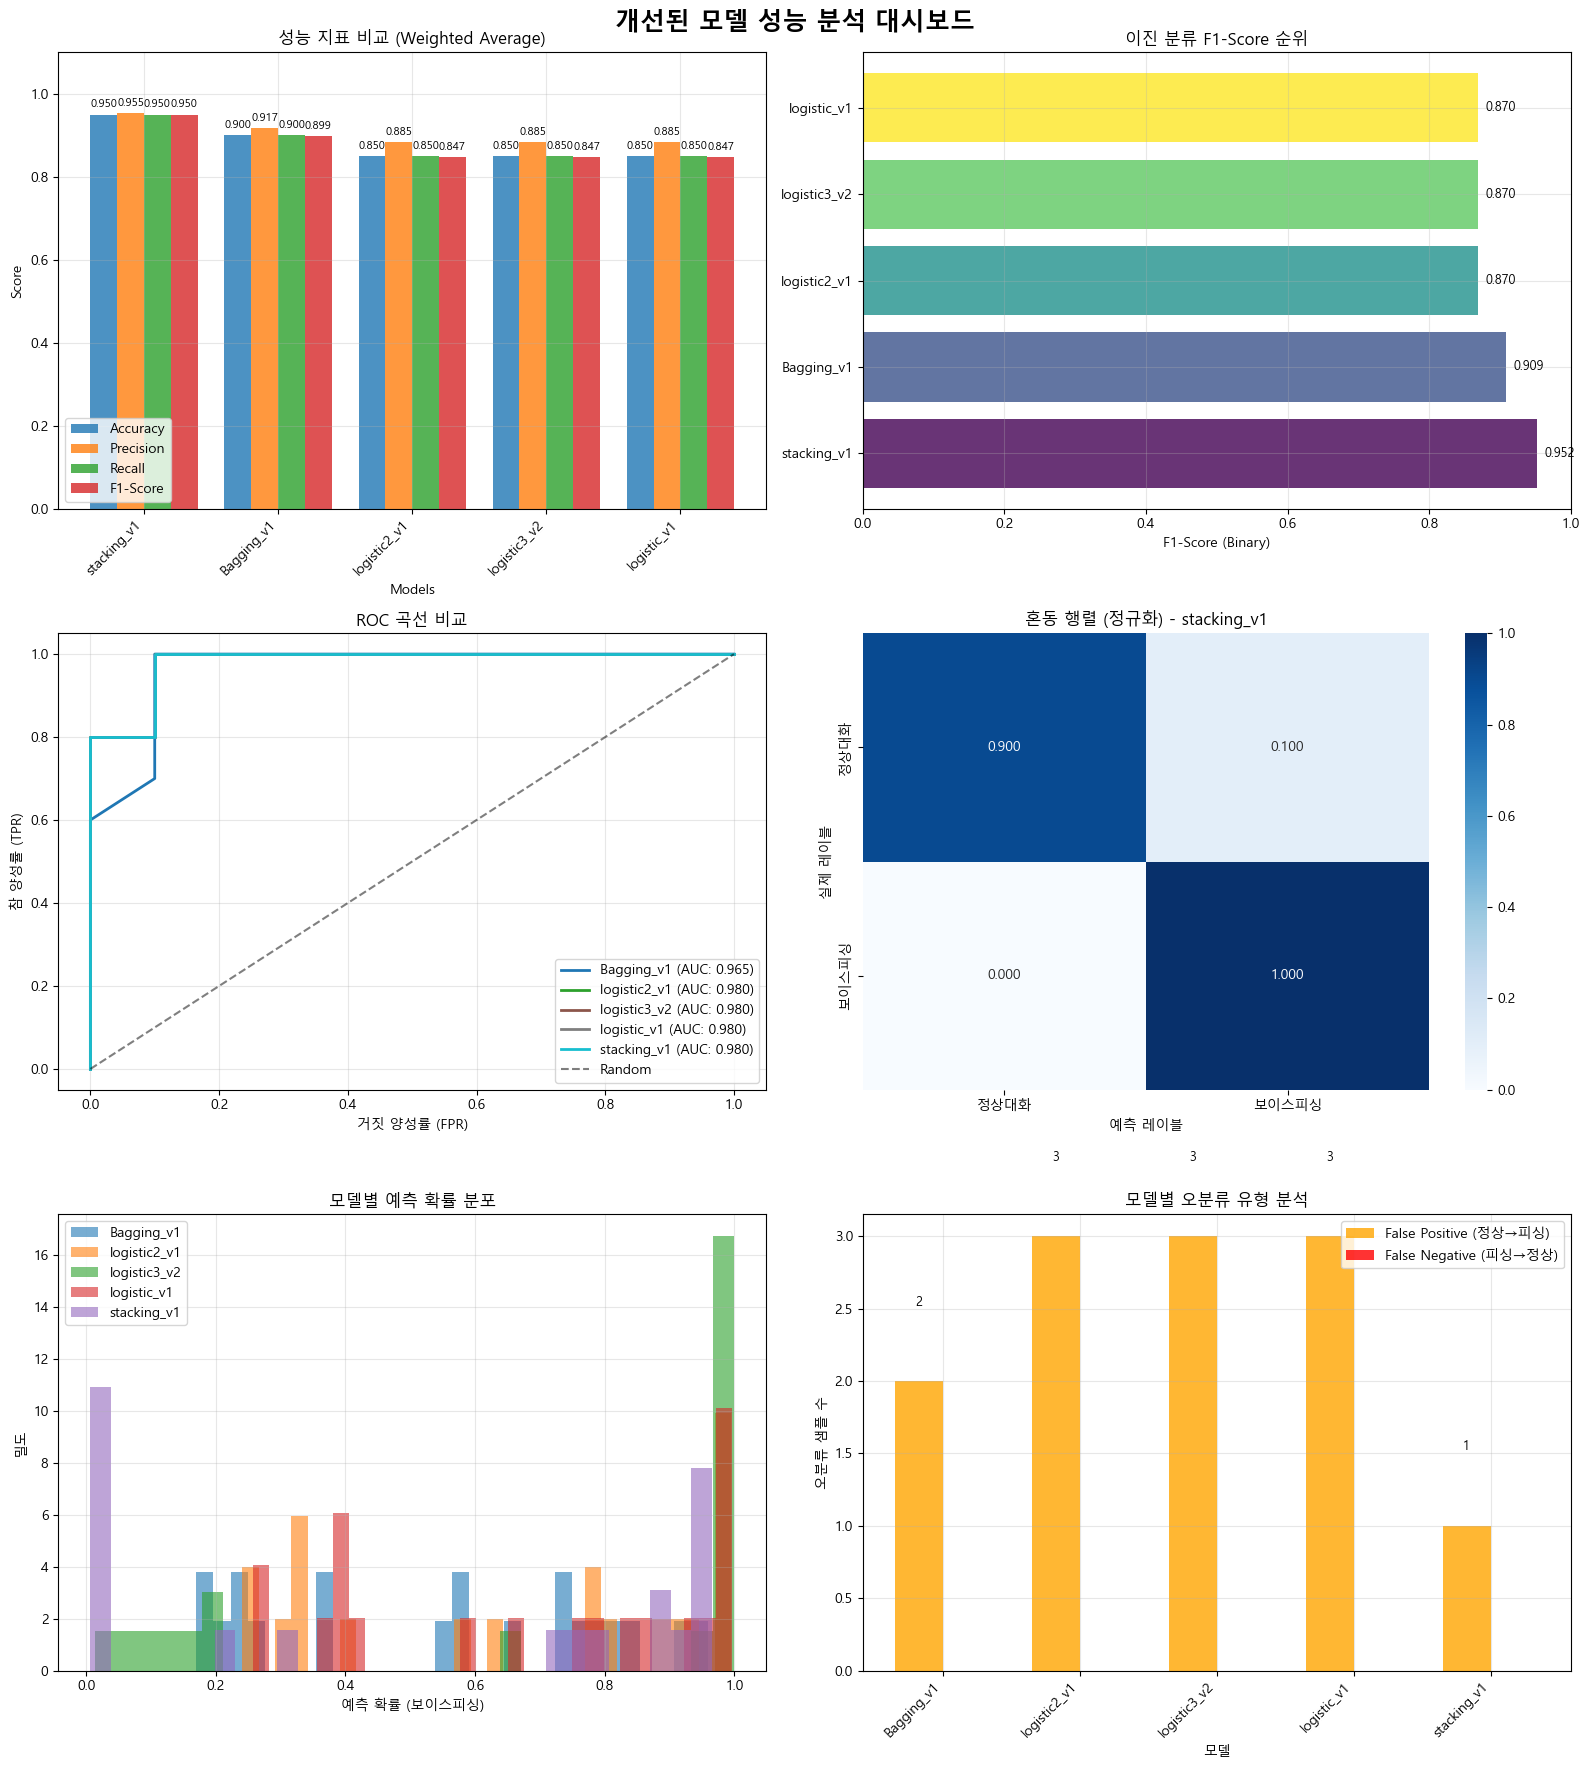

In [10]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["axes.unicode_minus"] = False
if platform.system() == "Windows":
    font_path = "C:/Windows/Fonts/malgun.ttf"
    font_name = font_manager.FontProperties(fname=font_path).get_name()
    rc("font", family=font_name)

# 개선된 모델 비교 시각화
if model_results:
    # 모델 이름을 더 읽기 쉽게 변환하는 함수
    def get_display_name(model_name):
        """긴 모델 이름을 읽기 쉬운 형태로 변환"""
        name_mapping = {
            "1차모델_원본데이터_pipeline_Ngram_kfold_로지스틱회귀": "N-gram K-fold 로지스틱회귀",
            "1차모델_원본데이터_pipeline_rf_Bagging": "Random Forest Bagging",
            "1차모델_원본데이터_pipeline_로지스틱회귀": "로지스틱회귀",
            "pipeline_stacking": "Stacking",
            "final_logistic_regression_model_6000_JJ": "통합데이터셋 로지스틱회귀"
        }
        return name_mapping.get(model_name, model_name)
    
    fig, axes = plt.subplots(3, 2, figsize=(16, 18))
    fig.suptitle('개선된 모델 성능 분석 대시보드', fontsize=18, fontweight='bold')
    
    # 1. 성능 지표 비교 (바 차트) - weighted 지표
    ax1 = axes[0, 0]
    metrics = ['Accuracy', 'Precision (weighted)', 'Recall (weighted)', 'F1-Score (weighted)']
    x_pos = np.arange(len(comparison_df))
    width = 0.2
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    for i, metric in enumerate(metrics):
        if metric in comparison_df.columns:
            bars = ax1.bar(x_pos + i*width, comparison_df[metric], width, 
                          label=metric.replace(' (weighted)', ''), alpha=0.8, color=colors[i])
            
            # 값 표시
            for bar in bars:
                height = bar.get_height()
                ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                        f'{height:.3f}', ha='center', va='bottom', fontsize=8)
    
    ax1.set_xlabel('Models')
    ax1.set_ylabel('Score')
    ax1.set_title('성능 지표 비교 (Weighted Average)')
    ax1.set_xticks(x_pos + width * 1.5)
    ax1.set_xticklabels([get_display_name(name) for name in comparison_df['Model']], rotation=45, ha='right')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, 1.1)
    
    # 2. 이진 분류 F1-Score 비교 (있는 경우)
    ax2 = axes[0, 1]
    if 'F1-Score (binary)' in comparison_df.columns:
        colors_f1 = plt.cm.viridis(np.linspace(0, 1, len(comparison_df)))
        bars = ax2.barh(range(len(comparison_df)), comparison_df['F1-Score (binary)'], 
                       color=colors_f1, alpha=0.8)
        ax2.set_yticks(range(len(comparison_df)))
        ax2.set_yticklabels([get_display_name(name) for name in comparison_df['Model']])
        ax2.set_xlabel('F1-Score (Binary)')
        ax2.set_title('이진 분류 F1-Score 순위')
        ax2.grid(True, alpha=0.3)
        
        # 값 표시
        for i, bar in enumerate(bars):
            width = bar.get_width()
            ax2.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
                    f'{width:.3f}', ha='left', va='center', fontsize=9)
    else:
        ax2.text(0.5, 0.5, 'Binary F1-Score\nNot Available', 
                ha='center', va='center', transform=ax2.transAxes, fontsize=12)
        ax2.set_title('이진 분류 F1-Score')
    
    # 3. ROC 곡선 비교
    ax3 = axes[1, 0]
    auc_available = any(result['auc'] is not None for result in model_results.values())
    
    if auc_available and len(np.unique(y_test)) == 2:
        colors_roc = plt.cm.tab10(np.linspace(0, 1, len(model_results)))
        for i, (model_name, results) in enumerate(model_results.items()):
            if results['probabilities'] is not None:
                fpr, tpr, _ = roc_curve(y_test, results['probabilities'])
                auc_score = results['auc']
                display_name = get_display_name(model_name)
                ax3.plot(fpr, tpr, label=f'{display_name} (AUC: {auc_score:.3f})', 
                        linewidth=2, color=colors_roc[i])
        
        ax3.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
        ax3.set_xlabel('거짓 양성률 (FPR)')
        ax3.set_ylabel('참 양성률 (TPR)')
        ax3.set_title('ROC 곡선 비교')
        ax3.legend(loc='lower right')
        ax3.grid(True, alpha=0.3)
    else:
        ax3.text(0.5, 0.5, 'ROC Curve\nNot Available', 
                ha='center', va='center', transform=ax3.transAxes, fontsize=12)
        ax3.set_title('ROC 곡선 비교')
    
    # 4. 혼동 행렬 히트맵 (최고 성능 모델)
    ax4 = axes[1, 1]
    if model_results:
        best_model_result = model_results[best_model]
        cm = best_model_result['confusion_matrix']
        
        # 정규화된 혼동 행렬
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
        sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='Blues', ax=ax4)
        ax4.set_title(f'혼동 행렬 (정규화) - {get_display_name(best_model)}')
        ax4.set_ylabel('실제 레이블')
        ax4.set_xlabel('예측 레이블')
        ax4.set_xticklabels(['정상대화', '보이스피싱'])
        ax4.set_yticklabels(['정상대화', '보이스피싱'])
    
    # 5. 예측 확률 분포 비교
    ax5 = axes[2, 0]
    for i, (model_name, results) in enumerate(model_results.items()):
        if results['probabilities'] is not None:
            probabilities = results['probabilities']
            display_name = get_display_name(model_name)
            ax5.hist(probabilities, bins=30, alpha=0.6, label=display_name, 
                    density=True, color=plt.cm.tab10(i))
    
    ax5.set_xlabel('예측 확률 (보이스피싱)')
    ax5.set_ylabel('밀도')
    ax5.set_title('모델별 예측 확률 분포')
    ax5.legend()
    ax5.grid(True, alpha=0.3)
    
    # 6. 오분류 샘플 분석
    ax6 = axes[2, 1]
    error_analysis = []
    for model_name, results in model_results.items():
        predictions = results['predictions']
        
        # False Positive와 False Negative 분리
        fp = np.sum((y_test == 0) & (predictions == 1))  # 정상을 피싱으로 잘못 분류
        fn = np.sum((y_test == 1) & (predictions == 0))  # 피싱을 정상으로 잘못 분류
        
        display_name = get_display_name(model_name)
        error_analysis.append([display_name, fp, fn])
    
    error_df = pd.DataFrame(error_analysis, columns=['모델', 'False Positive', 'False Negative'])
    
    x_pos = np.arange(len(error_df))
    width = 0.35
    
    fp_bars = ax6.bar(x_pos - width/2, error_df['False Positive'], width, 
                      label='False Positive (정상→피싱)', color='orange', alpha=0.8)
    fn_bars = ax6.bar(x_pos + width/2, error_df['False Negative'], width,
                      label='False Negative (피싱→정상)', color='red', alpha=0.8)
    
    ax6.set_xlabel('모델')
    ax6.set_ylabel('오분류 샘플 수')
    ax6.set_title('모델별 오분류 유형 분석')
    ax6.set_xticks(x_pos)
    ax6.set_xticklabels(error_df['모델'], rotation=45, ha='right')
    ax6.legend()
    ax6.grid(True, alpha=0.3)
    
    # 값 표시
    for bars in [fp_bars, fn_bars]:
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax6.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                        f'{int(height)}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    
    # 저장
    results_dir = "../../models/모델결과자료"
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    plt.savefig(os.path.join(results_dir, f'enhanced_model_analysis_{timestamp}.png'), 
                dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

else:
    print("시각화할 모델 결과가 없습니다.")

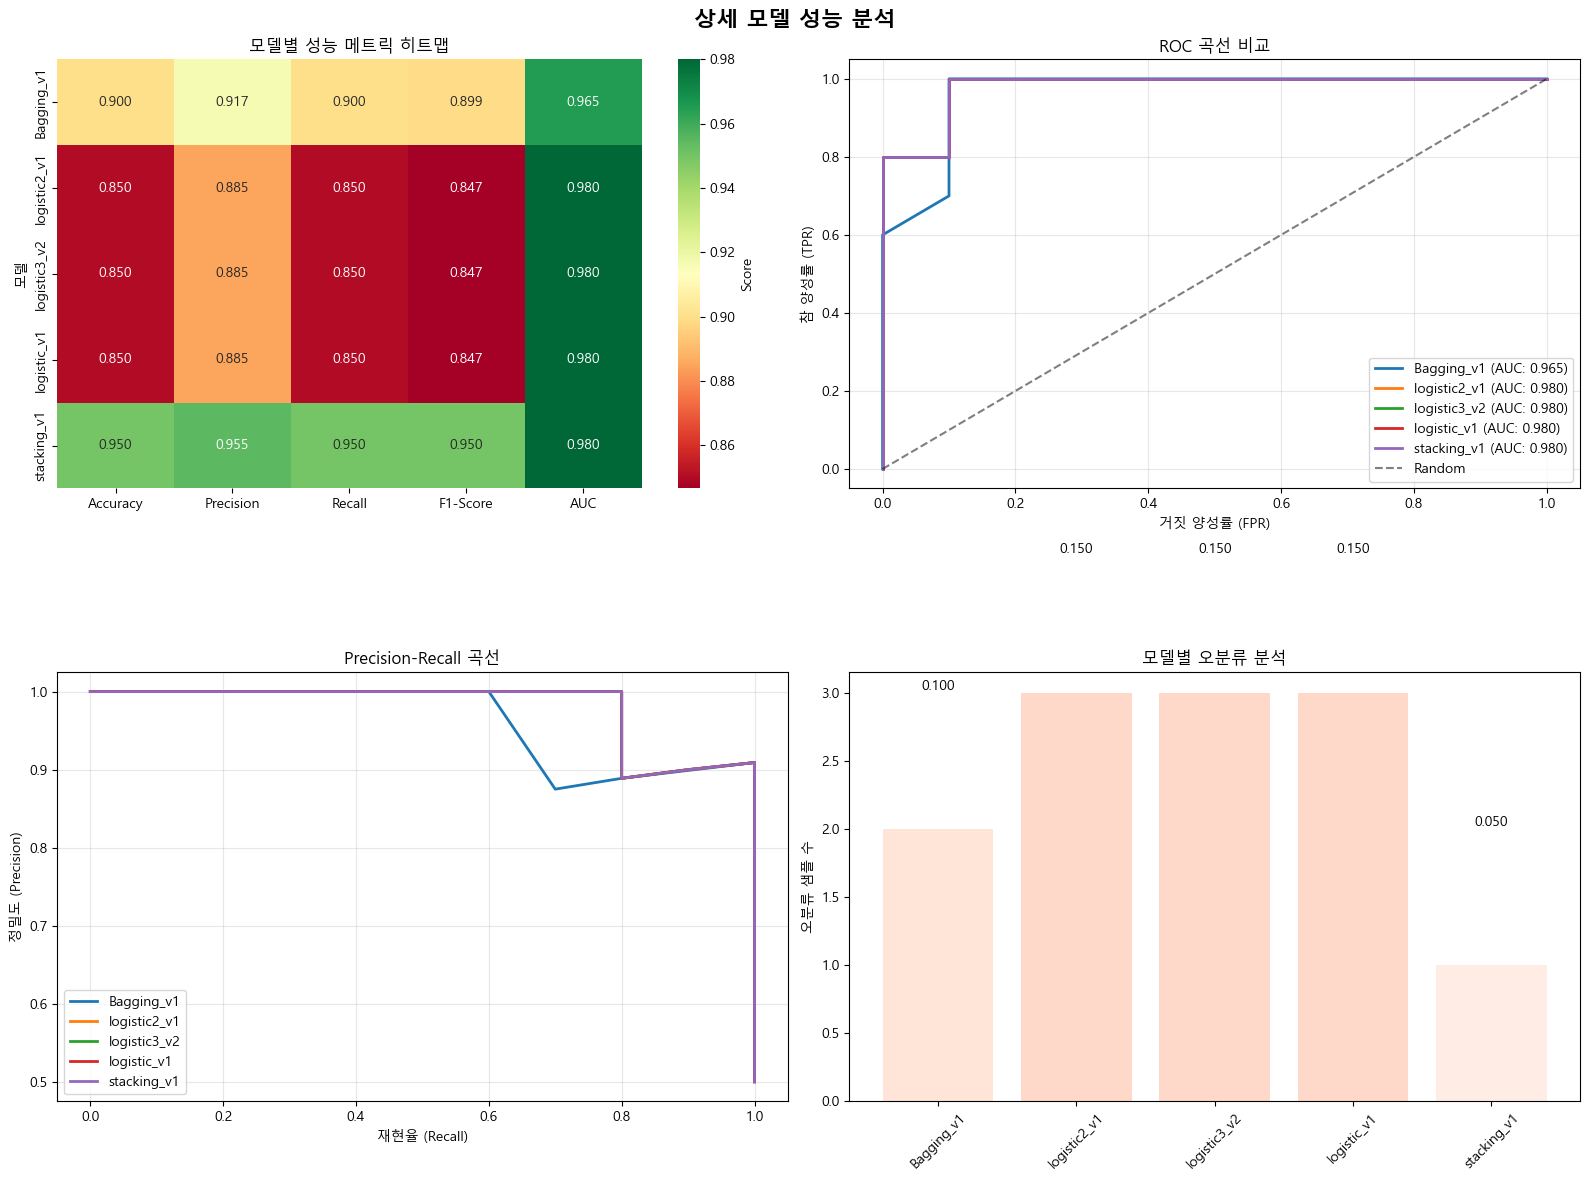

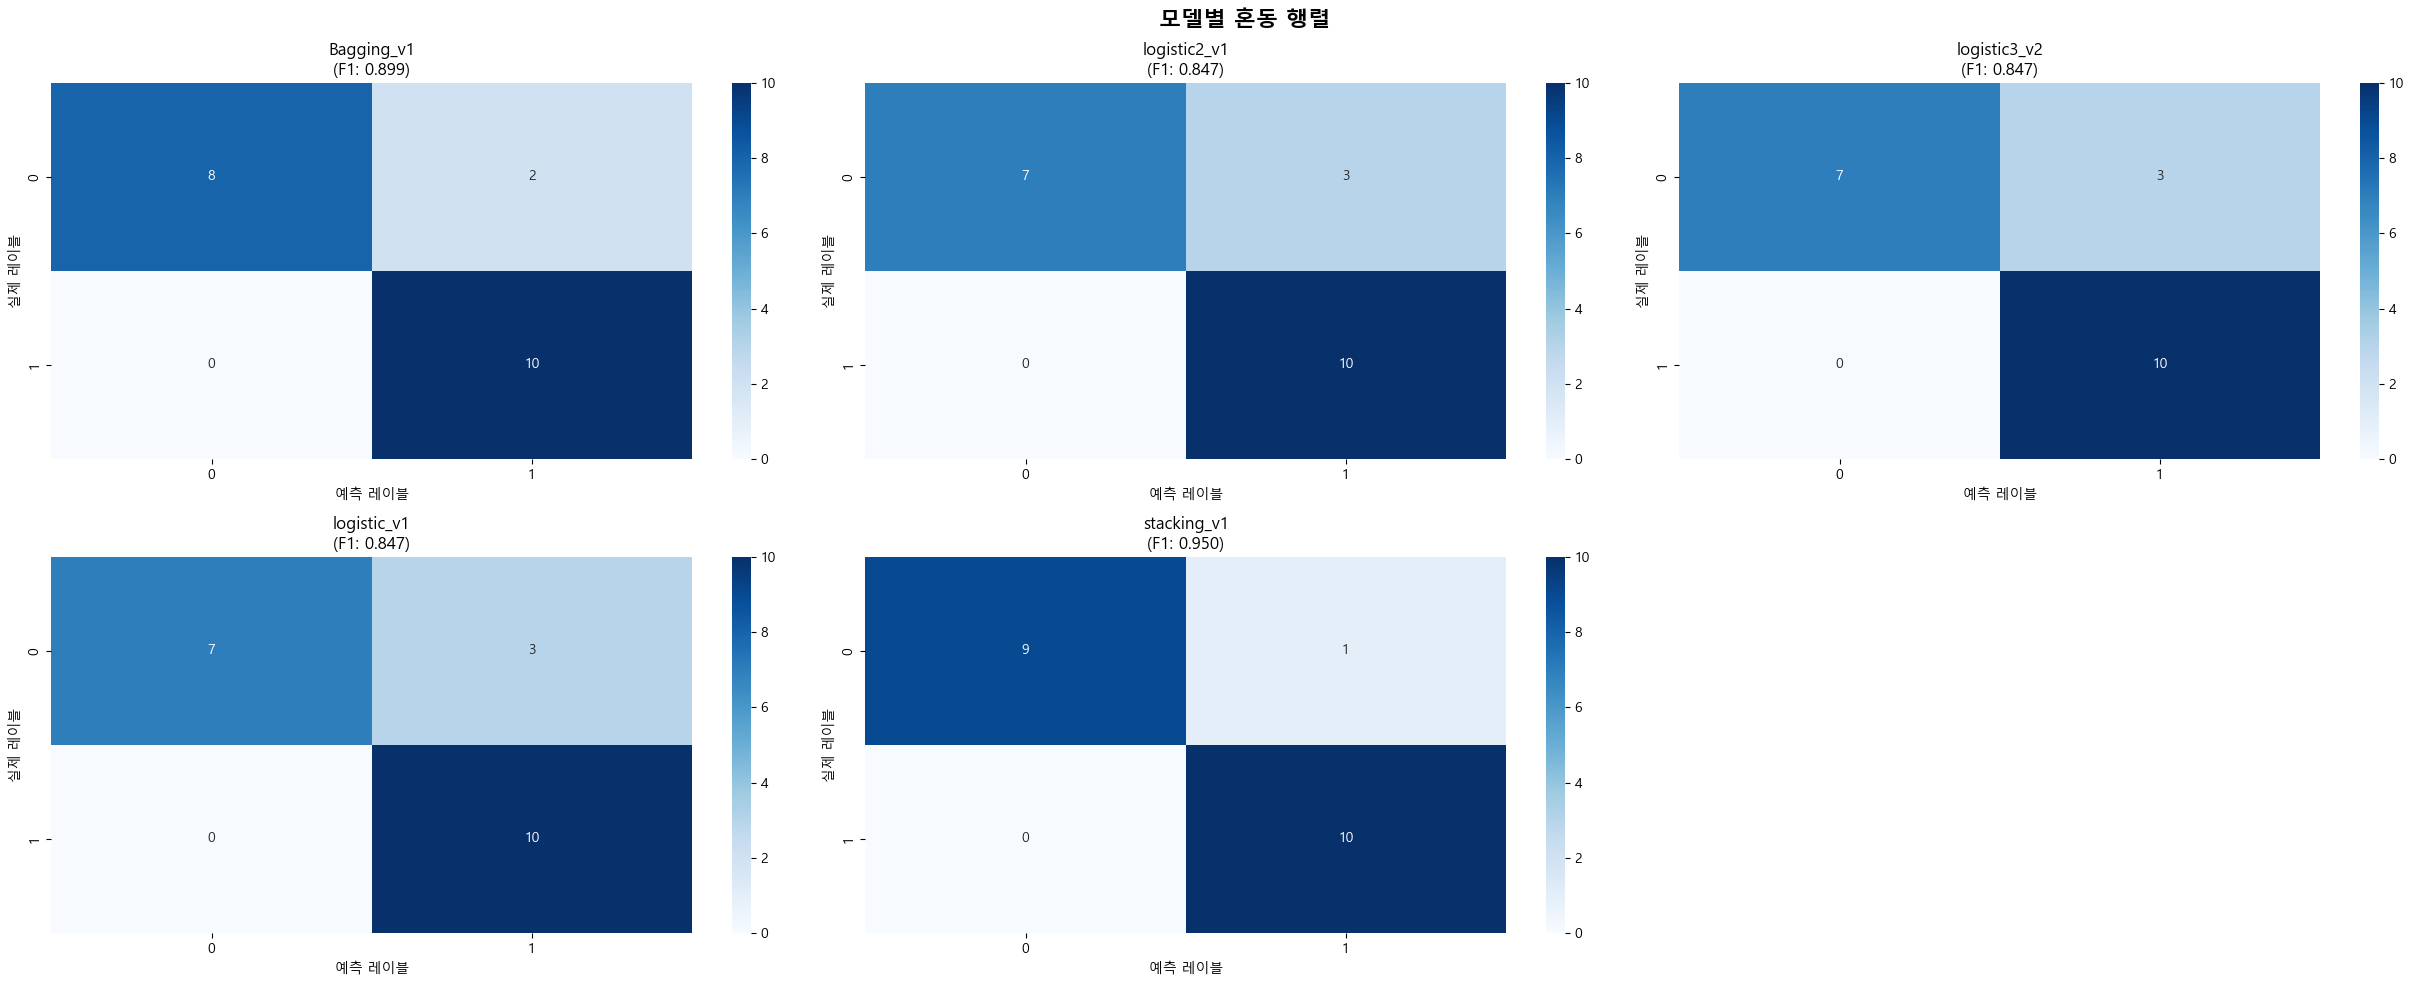

In [11]:
# 추가 성능 분석 및 시각화
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve
import koreanize_matplotlib

# # 한글 폰트 설정
# koreanize_matplotlib.init()

%matplotlib inline
plt.rcParams["axes.unicode_minus"] = False
if platform.system() == "Windows":
    font_path = "C:/Windows/Fonts/malgun.ttf"
    font_name = font_manager.FontProperties(fname=font_path).get_name()
    rc("font", family=font_name)

if model_results:
    # 성능 메트릭 히트맵
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('상세 모델 성능 분석', fontsize=16, fontweight='bold')
    
    # 모델 이름 변환 함수 (cell-13과 동일하게)
    def get_display_name(model_name):
        """긴 모델 이름을 읽기 쉬운 형태로 변환"""
        name_mapping = {
            "1차모델_원본데이터_pipeline_Ngram_kfold_로지스틱회귀": "N-gram K-fold 로지스틱회귀",
            "1차모델_원본데이터_pipeline_rf_Bagging": "Random Forest Bagging",
            "1차모델_원본데이터_pipeline_로지스틱회귀": "로지스틱회귀",
            "pipeline_stacking": "Stacking",
            "final_logistic_regression_model_6000_JJ": "통합데이터셋 로지스틱회귀"
        }
        return name_mapping.get(model_name, model_name)
    
    # 1. 성능 메트릭 히트맵
    ax1 = axes[0, 0]
    metrics_data = []
    model_names_short = []
    
    for model_name, results in model_results.items():
        display_name = get_display_name(model_name)
        model_names_short.append(display_name)
        metrics_data.append([
            results['accuracy'],
            results['precision'], 
            results['recall'],
            results['f1_score'],
            results['auc'] if results['auc'] else 0
        ])
    
    metrics_df = pd.DataFrame(metrics_data, 
                             index=model_names_short,
                             columns=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC'])
    
    sns.heatmap(metrics_df, annot=True, fmt='.3f', cmap='RdYlGn', 
                ax=ax1, cbar_kws={'label': 'Score'})
    ax1.set_title('모델별 성능 메트릭 히트맵')
    ax1.set_ylabel('모델')
    
    # 2. ROC 곡선 비교
    ax2 = axes[0, 1]
    if len(np.unique(y_test)) == 2:  # 이진 분류인 경우
        for model_name, results in model_results.items():
            if results['probabilities'] is not None:
                fpr, tpr, _ = roc_curve(y_test, results['probabilities'])
                auc_score = results['auc']
                display_name = get_display_name(model_name)
                ax2.plot(fpr, tpr, label=f'{display_name} (AUC: {auc_score:.3f})', linewidth=2)
        
        ax2.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
        ax2.set_xlabel('거짓 양성률 (FPR)')
        ax2.set_ylabel('참 양성률 (TPR)')
        ax2.set_title('ROC 곡선 비교')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
    
    # 3. Precision-Recall 곡선
    ax3 = axes[1, 0]
    if len(np.unique(y_test)) == 2:
        for model_name, results in model_results.items():
            if results['probabilities'] is not None:
                precision_vals, recall_vals, _ = precision_recall_curve(y_test, results['probabilities'])
                display_name = get_display_name(model_name)
                ax3.plot(recall_vals, precision_vals, label=display_name, linewidth=2)
        
        ax3.set_xlabel('재현율 (Recall)')
        ax3.set_ylabel('정밀도 (Precision)')
        ax3.set_title('Precision-Recall 곡선')
        ax3.legend()
        ax3.grid(True, alpha=0.3)
    
    # 4. 오분류 분석
    ax4 = axes[1, 1]
    error_analysis = []
    for model_name, results in model_results.items():
        predictions = results['predictions']
        misclassified = np.sum(y_test != predictions)
        error_rate = misclassified / len(y_test)
        display_name = get_display_name(model_name)
        error_analysis.append([display_name, misclassified, error_rate])
    
    error_df = pd.DataFrame(error_analysis, columns=['모델', '오분류수', '오분류율'])
    
    # 막대 그래프
    bars = ax4.bar(error_df['모델'], error_df['오분류수'], 
                   color=plt.cm.Reds(error_df['오분류율']))
    ax4.set_title('모델별 오분류 분석')
    ax4.set_ylabel('오분류 샘플 수')
    ax4.tick_params(axis='x', rotation=45)
    
    # 값 표시
    for bar, error_rate in zip(bars, error_df['오분류율']):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{error_rate:.3f}', ha='center', va='bottom')
    
    plt.tight_layout()
    
    # 저장 경로 설정
    results_dir = "../../models/모델결과자료"
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    plt.savefig(os.path.join(results_dir, f'detailed_analysis_plots_{timestamp}.png'), 
                dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    
    # 클래스별 성능 분석 (혼동 행렬 기반)
    fig, axes = plt.subplots(2, len(model_results)//2 + len(model_results)%2, 
                            figsize=(5*len(model_results), 10))
    if len(model_results) == 1:
        axes = [axes]
    elif len(model_results) <= 2:
        axes = axes.flatten()
    else:
        axes = axes.flatten()
    
    fig.suptitle('모델별 혼동 행렬', fontsize=16, fontweight='bold')
    
    for i, (model_name, results) in enumerate(model_results.items()):
        if i < len(axes):
            cm = results['confusion_matrix']
            display_name = get_display_name(model_name)
            
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
            axes[i].set_title(f'{display_name}\n(F1: {results["f1_score"]:.3f})')
            axes[i].set_ylabel('실제 레이블')
            axes[i].set_xlabel('예측 레이블')
    
    # 사용하지 않는 subplot 숨기기
    for j in range(len(model_results), len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, f'confusion_matrices_{timestamp}.png'), 
                dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()

else:
    print("시각화할 모델 결과가 없습니다.")

## 7. 상세 분석 리포트

In [12]:
# 각 모델별 상세 분석
if model_results:
    print("="*60)
    print("상세 모델 분석 리포트")
    print("="*60)
    
    for i, (model_name, results) in enumerate(model_results.items(), 1):
        print(f"\n{i}. {model_name} 모델")
        print("-" * 40)
        
        # 기본 성능 지표
        print(f"정확도 (Accuracy): {results['accuracy']:.4f}")
        print(f"정밀도 (Precision): {results['precision']:.4f}")
        print(f"재현율 (Recall): {results['recall']:.4f}")
        print(f"F1-Score: {results['f1_score']:.4f}")
        if results['auc']:
            print(f"AUC: {results['auc']:.4f}")
        
        # 혼동 행렬 분석
        cm = results['confusion_matrix']
        if cm.shape == (2, 2):  # 이진 분류
            tn, fp, fn, tp = cm.ravel()
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
            sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
            print(f"특이도 (Specificity): {specificity:.4f}")
            print(f"민감도 (Sensitivity): {sensitivity:.4f}")
            print(f"거짓양성률 (FPR): {fp / (fp + tn) if (fp + tn) > 0 else 0:.4f}")
        
        # 오분류 분석
        predictions = results['predictions']
        misclassified = np.sum(y_test != predictions)
        total_samples = len(y_test)
        error_rate = misclassified / total_samples
        
        print(f"오분류 샘플 수: {misclassified}/{total_samples}")
        print(f"오분류율: {error_rate:.4f} ({error_rate*100:.1f}%)")
        
        # 예측 신뢰도 분석
        if results['probabilities'] is not None:
            probas = results['probabilities']
            avg_confidence = np.mean(probas)
            confidence_std = np.std(probas)
            print(f"평균 예측 신뢰도: {avg_confidence:.4f}")
            print(f"신뢰도 표준편차: {confidence_std:.4f}")
            
            # 고신뢰도 예측 분석
            high_conf_threshold = 0.8
            high_conf_predictions = probas >= high_conf_threshold
            if np.any(high_conf_predictions):
                high_conf_accuracy = accuracy_score(
                    y_test[high_conf_predictions], 
                    predictions[high_conf_predictions]
                )
                print(f"고신뢰도(≥{high_conf_threshold}) 예측 정확도: {high_conf_accuracy:.4f}")
                print(f"고신뢰도 예측 비율: {np.mean(high_conf_predictions):.4f}")

# 모델 간 상호 분석
if len(model_results) > 1:
    print("\n" + "="*60)
    print("모델 간 비교 분석")
    print("="*60)
    
    # 예측 일치도 분석
    model_names = list(model_results.keys())
    predictions_matrix = np.array([model_results[name]['predictions'] for name in model_names])
    
    print("\n모델 간 예측 일치도 매트릭스:")
    agreement_matrix = np.zeros((len(model_names), len(model_names)))
    
    for i, name1 in enumerate(model_names):
        for j, name2 in enumerate(model_names):
            if i != j:
                pred1 = model_results[name1]['predictions']
                pred2 = model_results[name2]['predictions']
                agreement = np.mean(pred1 == pred2)
                agreement_matrix[i, j] = agreement
            else:
                agreement_matrix[i, j] = 1.0
    
    agreement_df = pd.DataFrame(agreement_matrix, 
                               index=model_names, 
                               columns=model_names)
    print(agreement_df.round(3))
    
    # 앙상블 성능 예측
    if len(model_names) >= 2:
        print(f"\n앙상블 예측 분석:")
        # 다수결 투표
        ensemble_pred = np.apply_along_axis(
            lambda x: np.bincount(x).argmax(), 
            axis=0, 
            arr=predictions_matrix
        )
        ensemble_accuracy = accuracy_score(y_test, ensemble_pred)
        print(f"다수결 앙상블 정확도: {ensemble_accuracy:.4f}")
        
        # 가중 평균 (확률 기반)
        prob_models = [name for name in model_names 
                      if model_results[name]['probabilities'] is not None]
        if len(prob_models) >= 2:
            proba_matrix = np.array([model_results[name]['probabilities'] 
                                   for name in prob_models])
            avg_proba = np.mean(proba_matrix, axis=0)
            weighted_pred = (avg_proba > 0.5).astype(int)
            weighted_accuracy = accuracy_score(y_test, weighted_pred)
            print(f"가중평균 앙상블 정확도: {weighted_accuracy:.4f}")

상세 모델 분석 리포트

1. Bagging_v1 모델
----------------------------------------
정확도 (Accuracy): 0.9000
정밀도 (Precision): 0.9167
재현율 (Recall): 0.9000
F1-Score: 0.8990
AUC: 0.9650
특이도 (Specificity): 0.8000
민감도 (Sensitivity): 1.0000
거짓양성률 (FPR): 0.2000
오분류 샘플 수: 2/20
오분류율: 0.1000 (10.0%)
평균 예측 신뢰도: 0.5460
신뢰도 표준편차: 0.2634
고신뢰도(≥0.8) 예측 정확도: 1.0000
고신뢰도 예측 비율: 0.2000

2. logistic2_v1 모델
----------------------------------------
정확도 (Accuracy): 0.8500
정밀도 (Precision): 0.8846
재현율 (Recall): 0.8500
F1-Score: 0.8465
AUC: 0.9800
특이도 (Specificity): 0.7000
민감도 (Sensitivity): 1.0000
거짓양성률 (FPR): 0.3000
오분류 샘플 수: 3/20
오분류율: 0.1500 (15.0%)
평균 예측 신뢰도: 0.6698
신뢰도 표준편차: 0.2839
고신뢰도(≥0.8) 예측 정확도: 0.8889
고신뢰도 예측 비율: 0.4500

3. logistic3_v2 모델
----------------------------------------
정확도 (Accuracy): 0.8500
정밀도 (Precision): 0.8846
재현율 (Recall): 0.8500
F1-Score: 0.8465
AUC: 0.9800
특이도 (Specificity): 0.7000
민감도 (Sensitivity): 1.0000
거짓양성률 (FPR): 0.3000
오분류 샘플 수: 3/20
오분류율: 0.1500 (15.0%)
평균 예측 신뢰도: 0.6694
신뢰도 표준편차: 0.4

✓ 모델 비교 결과가 '../../models/모델결과자료\model_comparison_results_20250722_001254.csv'에 저장되었습니다.
✓ 상세 모델 결과가 '../../models/모델결과자료\detailed_model_results_20250722_001254.csv'에 저장되었습니다.
✓ 모든 모델의 예측 결과가 '../../models/모델결과자료\model_predictions_20250722_001254.csv'에 저장되었습니다.
✓ 시각화 결과가 '../../models/모델결과자료/model_comparison_plots_20250722_001254.png'에 저장되었습니다.
✓ 요약 리포트가 '../../models/모델결과자료\model_test_summary_20250722_001254.txt'에 저장되었습니다.
✓ JSON 요약이 '../../models/모델결과자료\results_summary_20250722_001254.json'에 저장되었습니다.

📊 모든 결과가 models/모델결과자료 폴더에 저장되었습니다!
생성된 파일들:
• model_comparison_results_20250722_001254.csv - 모델 성능 비교표
• detailed_model_results_20250722_001254.csv - 상세 성능 지표
• model_predictions_20250722_001254.csv - 예측 결과
• model_comparison_plots_20250722_001254.png - 시각화 결과
• model_test_summary_20250722_001254.txt - 요약 리포트
• results_summary_20250722_001254.json - JSON 요약


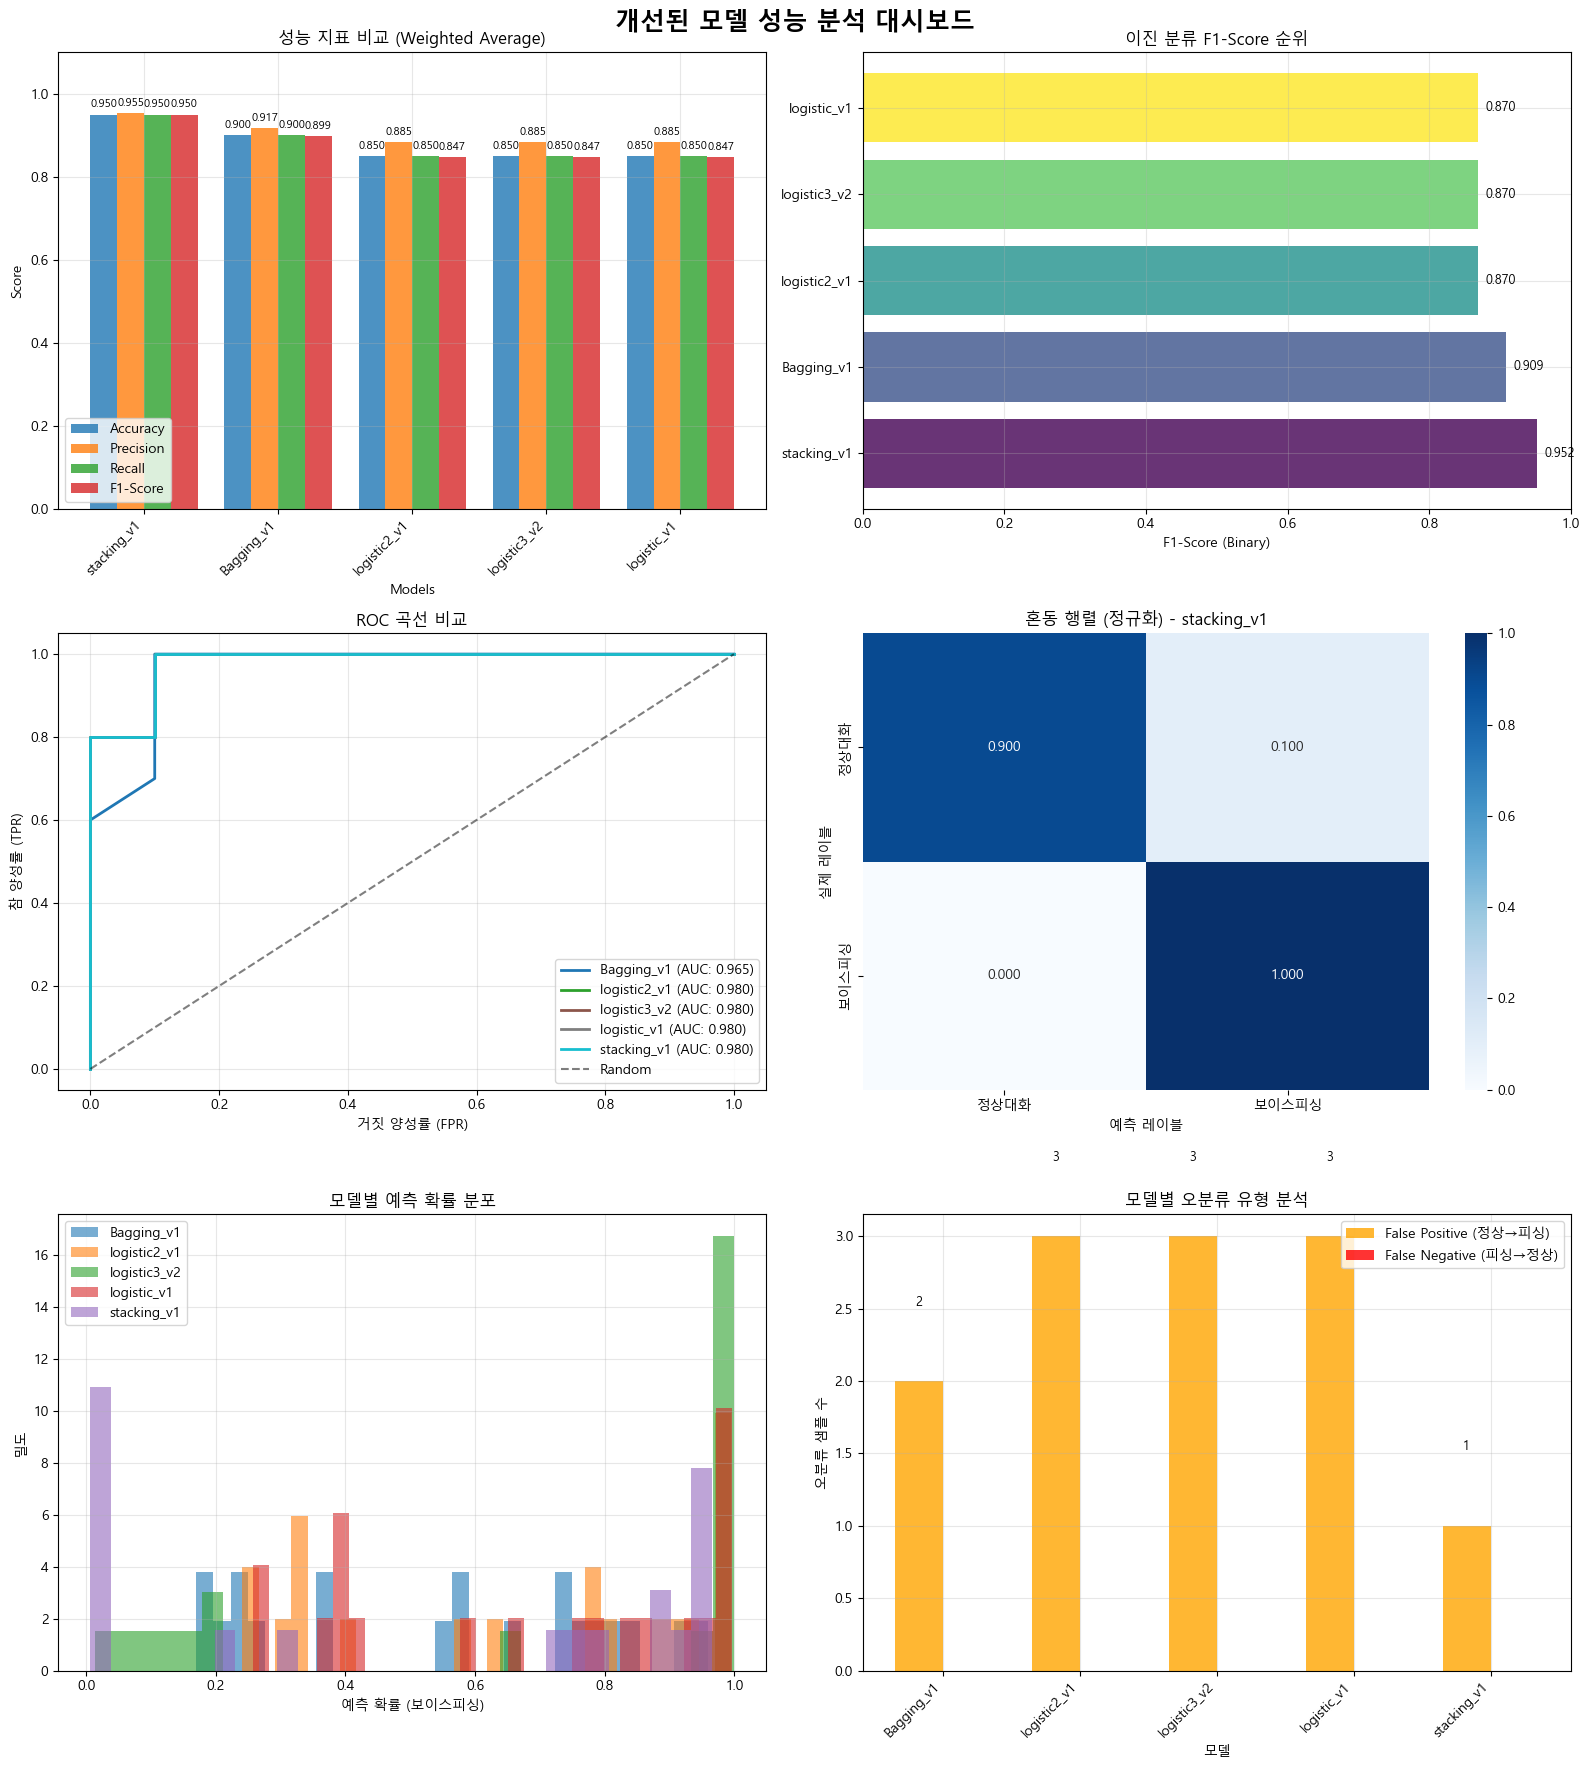

In [13]:
# 결과를 models/모델결과자료 폴더에 저장
import os
from datetime import datetime

# 저장 디렉토리 생성
results_dir = "../../models/모델결과자료"
os.makedirs(results_dir, exist_ok=True)

# 타임스탬프 추가
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

if model_results:
    # 1. 종합 성능 비교표 저장
    comparison_path = os.path.join(results_dir, f'model_comparison_results_{timestamp}.csv')
    comparison_df.to_csv(comparison_path, index=False, encoding='utf-8-sig')
    print(f"✓ 모델 비교 결과가 '{comparison_path}'에 저장되었습니다.")
    
    # 2. 상세 결과 저장
    detailed_results = []
    for model_name, results in model_results.items():
        detailed_result = {
            'Model': model_name,
            'Accuracy': results['accuracy'],
            'Precision': results['precision'],
            'Recall': results['recall'],
            'F1_Score': results['f1_score'],
            'AUC': results['auc'] if results['auc'] else 'N/A',
            'Total_Samples': len(y_test),
            'Misclassified': np.sum(y_test != results['predictions']),
            'Error_Rate': np.sum(y_test != results['predictions']) / len(y_test)
        }
        
        # 이진 분류인 경우 추가 지표
        if results['confusion_matrix'].shape == (2, 2):
            tn, fp, fn, tp = results['confusion_matrix'].ravel()
            detailed_result.update({
                'True_Negative': tn,
                'False_Positive': fp,
                'False_Negative': fn,
                'True_Positive': tp,
                'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
                'Sensitivity': tp / (tp + fn) if (tp + fn) > 0 else 0
            })
        
        detailed_results.append(detailed_result)
    
    detailed_df = pd.DataFrame(detailed_results)
    detailed_path = os.path.join(results_dir, f'detailed_model_results_{timestamp}.csv')
    detailed_df.to_csv(detailed_path, index=False, encoding='utf-8-sig')
    print(f"✓ 상세 모델 결과가 '{detailed_path}'에 저장되었습니다.")
    
    # 3. 예측 결과 저장
    predictions_df = pd.DataFrame({'True_Label': y_test})
    for model_name, results in model_results.items():
        predictions_df[f'{model_name}_Prediction'] = results['predictions']
        if results['probabilities'] is not None:
            predictions_df[f'{model_name}_Probability'] = results['probabilities']
    
    predictions_path = os.path.join(results_dir, f'model_predictions_{timestamp}.csv')
    predictions_df.to_csv(predictions_path, index=False, encoding='utf-8-sig')
    print(f"✓ 모든 모델의 예측 결과가 '{predictions_path}'에 저장되었습니다.")
    
    # 4. 시각화 결과 저장 - cell-13의 figure 재생성 후 저장
    # cell-13의 시각화 코드를 다시 실행하여 figure를 생성한 후 저장
    
    # 개선된 모델 비교 시각화 재생성
    def get_display_name(model_name):
        """긴 모델 이름을 읽기 쉬운 형태로 변환"""
        name_mapping = {
            "1차모델_원본데이터_pipeline_Ngram_kfold_로지스틱회귀": "N-gram K-fold 로지스틱회귀",
            "1차모델_원본데이터_pipeline_rf_Bagging": "Random Forest Bagging",
            "1차모델_원본데이터_pipeline_로지스틱회귀": "로지스틱회귀",
            "pipeline_stacking": "Stacking",
            "final_logistic_regression_model_6000_JJ": "통합데이터셋 로지스틱회귀"
        }
        return name_mapping.get(model_name, model_name)
    
    fig, axes = plt.subplots(3, 2, figsize=(16, 18))
    fig.suptitle('개선된 모델 성능 분석 대시보드', fontsize=18, fontweight='bold')
    
    # 1. 성능 지표 비교 (바 차트) - weighted 지표
    ax1 = axes[0, 0]
    metrics = ['Accuracy', 'Precision (weighted)', 'Recall (weighted)', 'F1-Score (weighted)']
    x_pos = np.arange(len(comparison_df))
    width = 0.2
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    for i, metric in enumerate(metrics):
        if metric in comparison_df.columns:
            bars = ax1.bar(x_pos + i*width, comparison_df[metric], width, 
                          label=metric.replace(' (weighted)', ''), alpha=0.8, color=colors[i])
            
            # 값 표시
            for bar in bars:
                height = bar.get_height()
                ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                        f'{height:.3f}', ha='center', va='bottom', fontsize=8)
    
    ax1.set_xlabel('Models')
    ax1.set_ylabel('Score')
    ax1.set_title('성능 지표 비교 (Weighted Average)')
    ax1.set_xticks(x_pos + width * 1.5)
    ax1.set_xticklabels([get_display_name(name) for name in comparison_df['Model']], rotation=45, ha='right')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, 1.1)
    
    # 2. 이진 분류 F1-Score 비교 (있는 경우)
    ax2 = axes[0, 1]
    if 'F1-Score (binary)' in comparison_df.columns:
        colors_f1 = plt.cm.viridis(np.linspace(0, 1, len(comparison_df)))
        bars = ax2.barh(range(len(comparison_df)), comparison_df['F1-Score (binary)'], 
                       color=colors_f1, alpha=0.8)
        ax2.set_yticks(range(len(comparison_df)))
        ax2.set_yticklabels([get_display_name(name) for name in comparison_df['Model']])
        ax2.set_xlabel('F1-Score (Binary)')
        ax2.set_title('이진 분류 F1-Score 순위')
        ax2.grid(True, alpha=0.3)
        
        # 값 표시
        for i, bar in enumerate(bars):
            width = bar.get_width()
            ax2.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
                    f'{width:.3f}', ha='left', va='center', fontsize=9)
    else:
        ax2.text(0.5, 0.5, 'Binary F1-Score\nNot Available', 
                ha='center', va='center', transform=ax2.transAxes, fontsize=12)
        ax2.set_title('이진 분류 F1-Score')
    
    # 3. ROC 곡선 비교
    ax3 = axes[1, 0]
    auc_available = any(result['auc'] is not None for result in model_results.values())
    
    if auc_available and len(np.unique(y_test)) == 2:
        colors_roc = plt.cm.tab10(np.linspace(0, 1, len(model_results)))
        for i, (model_name, results) in enumerate(model_results.items()):
            if results['probabilities'] is not None:
                fpr, tpr, _ = roc_curve(y_test, results['probabilities'])
                auc_score = results['auc']
                display_name = get_display_name(model_name)
                ax3.plot(fpr, tpr, label=f'{display_name} (AUC: {auc_score:.3f})', 
                        linewidth=2, color=colors_roc[i])
        
        ax3.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
        ax3.set_xlabel('거짓 양성률 (FPR)')
        ax3.set_ylabel('참 양성률 (TPR)')
        ax3.set_title('ROC 곡선 비교')
        ax3.legend(loc='lower right')
        ax3.grid(True, alpha=0.3)
    else:
        ax3.text(0.5, 0.5, 'ROC Curve\nNot Available', 
                ha='center', va='center', transform=ax3.transAxes, fontsize=12)
        ax3.set_title('ROC 곡선 비교')
    
    # 4. 혼동 행렬 히트맵 (최고 성능 모델)
    ax4 = axes[1, 1]
    if model_results:
        best_model_result = model_results[best_model]
        cm = best_model_result['confusion_matrix']
        
        # 정규화된 혼동 행렬
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
        sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='Blues', ax=ax4)
        ax4.set_title(f'혼동 행렬 (정규화) - {get_display_name(best_model)}')
        ax4.set_ylabel('실제 레이블')
        ax4.set_xlabel('예측 레이블')
        ax4.set_xticklabels(['정상대화', '보이스피싱'])
        ax4.set_yticklabels(['정상대화', '보이스피싱'])
    
    # 5. 예측 확률 분포 비교
    ax5 = axes[2, 0]
    for i, (model_name, results) in enumerate(model_results.items()):
        if results['probabilities'] is not None:
            probabilities = results['probabilities']
            display_name = get_display_name(model_name)
            ax5.hist(probabilities, bins=30, alpha=0.6, label=display_name, 
                    density=True, color=plt.cm.tab10(i))
    
    ax5.set_xlabel('예측 확률 (보이스피싱)')
    ax5.set_ylabel('밀도')
    ax5.set_title('모델별 예측 확률 분포')
    ax5.legend()
    ax5.grid(True, alpha=0.3)
    
    # 6. 오분류 샘플 분석
    ax6 = axes[2, 1]
    error_analysis = []
    for model_name, results in model_results.items():
        predictions = results['predictions']
        
        # False Positive와 False Negative 분리
        fp = np.sum((y_test == 0) & (predictions == 1))  # 정상을 피싱으로 잘못 분류
        fn = np.sum((y_test == 1) & (predictions == 0))  # 피싱을 정상으로 잘못 분류
        
        display_name = get_display_name(model_name)
        error_analysis.append([display_name, fp, fn])
    
    error_df = pd.DataFrame(error_analysis, columns=['모델', 'False Positive', 'False Negative'])
    
    x_pos = np.arange(len(error_df))
    width = 0.35
    
    fp_bars = ax6.bar(x_pos - width/2, error_df['False Positive'], width, 
                      label='False Positive (정상→피싱)', color='orange', alpha=0.8)
    fn_bars = ax6.bar(x_pos + width/2, error_df['False Negative'], width,
                      label='False Negative (피싱→정상)', color='red', alpha=0.8)
    
    ax6.set_xlabel('모델')
    ax6.set_ylabel('오분류 샘플 수')
    ax6.set_title('모델별 오분류 유형 분석')
    ax6.set_xticks(x_pos)
    ax6.set_xticklabels(error_df['모델'], rotation=45, ha='right')
    ax6.legend()
    ax6.grid(True, alpha=0.3)
    
    # 값 표시
    for bars in [fp_bars, fn_bars]:
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax6.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                        f'{int(height)}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    
    # 저장
    plt.savefig(os.path.join(results_dir, f'model_comparison_plots_{timestamp}.png'), 
                dpi=300, bbox_inches='tight', facecolor='white')
    print(f"✓ 시각화 결과가 '{results_dir}/model_comparison_plots_{timestamp}.png'에 저장되었습니다.")
    
    # 5. 실행 요약 텍스트 리포트 생성
    summary_path = os.path.join(results_dir, f'model_test_summary_{timestamp}.txt')
    with open(summary_path, 'w', encoding='utf-8') as f:
        f.write("1차 모델 성능 테스트 요약 리포트\n")
        f.write("=" * 50 + "\n\n")
        
        f.write(f"테스트 일시: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"테스트 데이터 크기: {len(y_test)}개 샘플\n")
        f.write(f"평가된 모델 수: {len(model_results)}개\n\n")
        
        f.write("모델별 성능 순위 (F1-Score 기준):\n")
        f.write("-" * 30 + "\n")
        for i, row in comparison_df.iterrows():
            f.write(f"{i+1}. {row['Model']}: {row['F1-Score (weighted)']:.4f}\n")
        
        f.write(f"\n최고 성능 모델: {best_model}\n")
        f.write(f"최고 F1-Score: {best_f1:.4f}\n")
        
        if len(comparison_df) > 1:
            f.write(f"성능 개선폭: {improvement:.1f}%\n")
        
        f.write("\n주요 인사이트:\n")
        f.write("-" * 15 + "\n")
        
        # 자동 인사이트 생성
        if best_f1 >= 0.9:
            f.write("• 우수한 모델 성능 - 프로덕션 배포 고려 가능\n")
        elif best_f1 >= 0.8:
            f.write("• 양호한 모델 성능 - 추가 튜닝으로 개선 가능\n")
        else:
            f.write("• 모델 성능 개선 필요 - 데이터/특성/하이퍼파라미터 검토 권장\n")
        
        if len(model_results) > 1:
            f.write(f"• {len(model_results)}개 모델 중 성능 차이가 존재 - 앙상블 기법 활용 검토\n")
        
        # AUC 분석
        auc_scores = [r['auc'] for r in model_results.values() if r['auc'] is not None]
        if auc_scores:
            max_auc = max(auc_scores)
            if max_auc >= 0.9:
                f.write("• 높은 AUC 성능 - 클래스 구분 능력 우수\n")
            elif max_auc < 0.7:
                f.write("• 낮은 AUC 성능 - 클래스 불균형 또는 특성 부족 검토 필요\n")
        
        # 상세 모델 분석 추가
        f.write("\n\n모델별 상세 분석:\n")
        f.write("=" * 30 + "\n")
        for model_name, results in model_results.items():
            f.write(f"\n{model_name}:\n")
            f.write(f"  - 정확도: {results['accuracy']:.4f}\n")
            f.write(f"  - 정밀도: {results['precision']:.4f}\n")
            f.write(f"  - 재현율: {results['recall']:.4f}\n")
            f.write(f"  - F1-Score: {results['f1_score']:.4f}\n")
            if results['auc']:
                f.write(f"  - AUC: {results['auc']:.4f}\n")
            
            # 혼동 행렬 정보
            cm = results['confusion_matrix']
            if cm.shape == (2, 2):
                tn, fp, fn, tp = cm.ravel()
                f.write(f"  - 혼동행렬: TN={tn}, FP={fp}, FN={fn}, TP={tp}\n")
    
    print(f"✓ 요약 리포트가 '{summary_path}'에 저장되었습니다.")
    
    # 6. JSON 형태로 모든 결과 저장 (추후 활용을 위해)
    import json
    results_summary = {
        'test_timestamp': timestamp,
        'test_data_size': len(y_test),
        'models_evaluated': len(model_results),
        'best_model': best_model,
        'best_f1_score': float(best_f1),
        'model_rankings': comparison_df.to_dict('records')
    }
    
    json_path = os.path.join(results_dir, f'results_summary_{timestamp}.json')
    with open(json_path, 'w', encoding='utf-8') as f:
        json.dump(results_summary, f, ensure_ascii=False, indent=2)
    print(f"✓ JSON 요약이 '{json_path}'에 저장되었습니다.")
    
    print("\n" + "="*60)
    print("📊 모든 결과가 models/모델결과자료 폴더에 저장되었습니다!")
    print("="*60)
    print("생성된 파일들:")
    print(f"• model_comparison_results_{timestamp}.csv - 모델 성능 비교표")
    print(f"• detailed_model_results_{timestamp}.csv - 상세 성능 지표")
    print(f"• model_predictions_{timestamp}.csv - 예측 결과")
    print(f"• model_comparison_plots_{timestamp}.png - 시각화 결과")
    print(f"• model_test_summary_{timestamp}.txt - 요약 리포트")
    print(f"• results_summary_{timestamp}.json - JSON 요약")
    
else:
    print("저장할 모델 결과가 없습니다.")

## 9. 최종 결론 및 권장사항

In [14]:
# 최종 결론 및 권장사항
if model_results:
    print("🎯 최종 결론 및 권장사항")
    print("=" * 50)
    
    # 1. 최고 성능 모델 추천
    print(f"\\n1. 추천 모델: {best_model}")
    print(f"   - F1-Score: {best_f1:.4f}")
    best_accuracy = model_results[best_model]['accuracy']
    print(f"   - 정확도: {best_accuracy:.4f}")
    
    if model_results[best_model]['auc']:
        best_auc = model_results[best_model]['auc']
        print(f"   - AUC: {best_auc:.4f}")
    
    # 2. 성능 해석
    print(f"\\n2. 성능 해석:")
    if best_f1 >= 0.9:
        print("   ✅ 우수한 성능 - 실제 배포에 적합")
        print("   📋 권장사항: 프로덕션 환경에서 추가 검증 후 배포")
    elif best_f1 >= 0.8:
        print("   ⚡ 양호한 성능 - 개선 여지 존재")
        print("   📋 권장사항: 하이퍼파라미터 튜닝 또는 특성 엔지니어링으로 개선")
    elif best_f1 >= 0.7:
        print("   ⚠️  보통 성능 - 추가 개선 필요")
        print("   📋 권장사항: 데이터 품질, 특성 선택, 모델 아키텍처 재검토")
    else:
        print("   ❌ 성능 개선 필요")
        print("   📋 권장사항: 전반적인 모델링 전략 재검토 필요")
    
    # 3. 모델별 특성 분석
    if len(model_results) > 1:
        print(f"\\n3. 모델 특성 분석:")
        
        # 성능 편차 분석
        f1_scores = [results['f1_score'] for results in model_results.values()]
        f1_std = np.std(f1_scores)
        
        if f1_std < 0.05:
            print("   📊 모델 간 성능 차이가 작음 - 일관된 데이터 품질")
        else:
            print("   📊 모델 간 성능 차이가 큼 - 모델별 특성 고려 필요")
        
        # 앙상블 추천
        if len(model_results) >= 3:
            print("   🤝 앙상블 모델 고려사항:")
            print("     - 다수결 투표 또는 가중평균 앙상블로 성능 향상 가능")
            print("     - 성능 차이가 있는 모델들을 조합하여 강건성 증대")
    
    # 4. 다음 단계 제안
    print(f"\\n4. 다음 단계 제안:")
    print("   🔄 모델 개선:")
    print("     - 하이퍼파라미터 최적화 (GridSearch, RandomSearch)")
    print("     - 교차 검증을 통한 모델 안정성 확인")
    print("     - 특성 중요도 분석 및 특성 선택")
    
    if any(results['auc'] and results['auc'] < 0.8 for results in model_results.values()):
        print("   📈 데이터 개선:")
        print("     - 클래스 불균형 해결 (SMOTE, 언더샘플링 등)")
        print("     - 추가 특성 엔지니어링")
        print("     - 이상치 탐지 및 처리")
    
    print("   🚀 배포 준비:")
    print("     - 모델 해석가능성 분석 (SHAP, LIME)")
    print("     - A/B 테스트를 통한 실제 성능 검증")
    print("     - 모델 모니터링 및 성능 추적 체계 구축")
    
    # 5. 비즈니스 관점 권장사항
    print(f"\\n5. 비즈니스 관점 권장사항:")
    
    error_rate = 1 - best_accuracy
    if error_rate <= 0.05:
        print("   💼 높은 신뢰도로 자동화 의사결정 가능")
    elif error_rate <= 0.1:
        print("   💼 인간 검토와 함께 반자동화 추천")
    else:
        print("   💼 의사결정 보조 도구로 활용 권장")
    
    print(f"   💰 예상 오류율: {error_rate*100:.1f}%")
    print("   📊 정기적인 모델 성능 모니터링 필수")
    
else:
    print("분석할 모델 결과가 없습니다.")

print("\\n" + "="*50)
print("🏁 1차 모델 테스트 완료!")
print("모든 결과 파일이 저장되었습니다.")
print("="*50)

🎯 최종 결론 및 권장사항
\n1. 추천 모델: stacking_v1
   - F1-Score: 0.9499
   - 정확도: 0.9500
   - AUC: 0.9800
\n2. 성능 해석:
   ✅ 우수한 성능 - 실제 배포에 적합
   📋 권장사항: 프로덕션 환경에서 추가 검증 후 배포
\n3. 모델 특성 분석:
   📊 모델 간 성능 차이가 작음 - 일관된 데이터 품질
   🤝 앙상블 모델 고려사항:
     - 다수결 투표 또는 가중평균 앙상블로 성능 향상 가능
     - 성능 차이가 있는 모델들을 조합하여 강건성 증대
\n4. 다음 단계 제안:
   🔄 모델 개선:
     - 하이퍼파라미터 최적화 (GridSearch, RandomSearch)
     - 교차 검증을 통한 모델 안정성 확인
     - 특성 중요도 분석 및 특성 선택
   🚀 배포 준비:
     - 모델 해석가능성 분석 (SHAP, LIME)
     - A/B 테스트를 통한 실제 성능 검증
     - 모델 모니터링 및 성능 추적 체계 구축
\n5. 비즈니스 관점 권장사항:
   💼 인간 검토와 함께 반자동화 추천
   💰 예상 오류율: 5.0%
   📊 정기적인 모델 성능 모니터링 필수
\n==================================================
🏁 1차 모델 테스트 완료!
모든 결과 파일이 저장되었습니다.
